# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2384 Поглазов Никита Васильевич и Вовченко София Евгеньевна. Вариант 14.

## Цель работы

 Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи. 

## Основные теоретические положения

**Метод наименьших квадратов (МНК)** — математический метод, основанный на минимизации суммы квадратов отклонений экспериментальных данных от расчетных значений (заданных функцией). В регрессионном анализе МНК используется для оценки неизвестных параметров регрессионных моделей.

Для простой линейной модели $y = \beta_0 + \beta_1x$ оценки параметров находятся из условия минимума функции невязок:
$$Q(\beta_0, \beta_1) = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n (y_i - (\beta_0 + \beta_1 x_i))^2 \to \min$$

**Уравнения выборочных прямых среднеквадратической регрессии:**
* Регрессия $Y$ на $X$: $\hat{y} = \bar{y} + r_{xy} \frac{S_y}{S_x} (x - \bar{x})$, что соответствует $y = \beta_0 + \beta_1 x$
* Регрессия $X$ на $Y$: $\hat{x} = \bar{x} + r_{xy} \frac{S_x}{S_y} (y - \bar{y})$, что соответствует $x = \beta_0' + \beta_1' y$

где $\bar{x}, \bar{y}$ — выборочные средние, $S_x, S_y$ — выборочные средние квадратические отклонения, $r_{xy}$ — выборочный коэффициент линейной корреляции.

**Корреляционное отношение ($\eta$)** — мера тесноты любой (в том числе нелинейной) корреляционной связи. 
* Эмпирическое корреляционное отношение $Y$ к $X$ определяется как:
$$\eta_{yx} = \sqrt{\frac{D_{\text{межгр}}}{D_{\text{общ}}}}$$
где $D_{\text{межгр}}$ — дисперсия групповых средних вокруг общей средней (объясненная дисперсия), $D_{\text{общ}}$ — общая дисперсия признака $Y$.

**Теоретический коэффициент детерминации ($R^2$)**: показывает долю дисперсии зависимой переменной, которую объясняет построенная регрессионная модель. Чем ближе $R^2$ к 1, тем выше качество аппроксимации.
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
**Средняя квадратическая ошибка ($S_{\varepsilon}$)**: абсолютная мера разброса данных вокруг линии регрессии.
$$S_{\varepsilon} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$
**Средняя ошибка аппроксимации ($\bar{A}$)**: оценивает среднее относительное отклонение расчетных значений от фактических.
$$\bar{A} = \frac{1}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right| \cdot 100\%$$

## Постановка задачи

Для заданной двумерной выборки $(X, Y)$ построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display_markdown

In [2]:
df = pd.read_csv('../samples.csv')

- Отобразить двумерную выборку на графике.


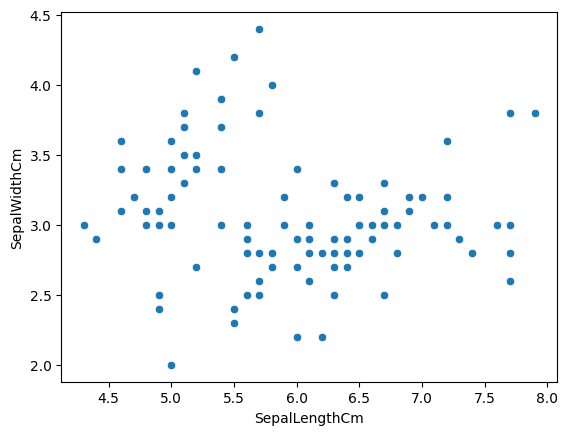

In [6]:
sns.scatterplot(data=df, x='SepalLengthCm', y='SepalWidthCm')
plt.show()

- Для заданной выборки построить уравнения средней квадратичной регрессии $ x $ на $ y $ и $ y $ на $ x $ соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.


In [38]:
def fit_linear_regression(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    beta_0 = y_mean - beta_1 * x_mean
    
    return beta_0, beta_1

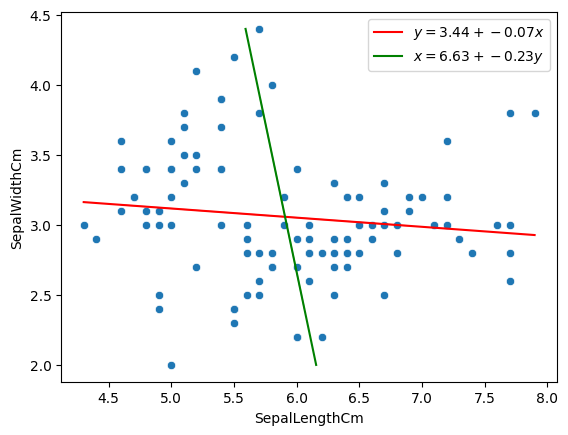

In [63]:
x = df['SepalLengthCm'].to_numpy()
y = df['SepalWidthCm'].to_numpy()
beta_xy_0, beta_xy_1 = fit_linear_regression(x, y)
beta_yx_0, beta_yx_1 = fit_linear_regression(y, x)

sns.scatterplot(data=df, x='SepalLengthCm', y='SepalWidthCm')
sns.lineplot(x=x, y=beta_xy_0 + beta_xy_1 * x, color='red', label=rf'$y = {beta_xy_0:.2f} + {beta_xy_1:.2f} x$')
sns.lineplot(x=beta_yx_0 + beta_yx_1 * y, y=y, color='green', label=rf'$x = {beta_yx_0:.2f} + {beta_yx_1:.2f} y$')
plt.show()

Построенные прямые регрессии $x$ на $y$ и $y$ на $x$ показывают слабую линейную зависимость между длиной и шириной чашелистика. Прямые расположены под существенным углом друг к другу, что характерно для выборок с низким парным коэффициентом корреляции.

- Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $ \eta_{xy} \geqslant |r_{xy}| $ и $ \eta_{yx} \geqslant |r_{xy}| $ выполняются.


In [14]:
def compute_correlation_ratio(x: np.ndarray, y: np.ndarray, bins: int = 10) -> float:
    x_bins = pd.cut(x, bins=bins, labels=False)
    
    y_mean_global = np.mean(y)
    sst_total = np.sum((y - y_mean_global) ** 2)
    
    df_grouped = pd.DataFrame({'x_bin': x_bins, 'y': y})
    grouped = df_grouped.groupby('x_bin')['y']
    
    ss_between = 0.0
    for _, group in grouped:
        n_k = len(group)
        y_mean_k = group.mean()
        ss_between += n_k * ((y_mean_k - y_mean_global) ** 2)
        
    eta_squared = ss_between / sst_total
    return np.sqrt(eta_squared)

In [32]:
r_xy = np.corrcoef(x, y)[0, 1]
r_xy_abs = abs(r_xy)

n_bins = int(1 + 3.322 * np.log10(len(x)))
eta_yx = compute_correlation_ratio(x, y, bins=n_bins)
eta_xy = compute_correlation_ratio(y, x, bins=n_bins)

display_markdown(rf"$\eta_{{yx}} \geq |r_{{xy}}|$ : ${eta_yx:.4f} \geq {r_xy_abs:.4f}$", raw=True)
display_markdown(rf"$\eta_{{xy}} \geq |r_{{xy}}|$ : ${eta_xy:.4f} \geq {r_xy_abs:.4f}$", raw=True)

$\eta_{yx} \geq |r_{xy}|$ : $0.3182 \geq 0.1239$

$\eta_{xy} \geq |r_{xy}|$ : $0.3829 \geq 0.1239$

- Для заданной выборки построить корреляционную кривую параболического вида $ y = \beta_0 + \beta_1x + \beta_2x^2 $, сделать выводы.


In [33]:
def fit_quadratic_regression(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    x2 = x ** 2
    x2_mean = np.mean(x2)
    
    xy = x * y
    xy_mean = np.mean(xy)
    
    A = np.array([[1, x_mean, x2_mean],
                  [x_mean, x2_mean, np.mean(x**3)],
                  [x2_mean, np.mean(x**3), np.mean(x**4)]])
    
    b = np.array([y_mean, xy_mean, np.mean(x2 * y)])
    
    coeffs = np.linalg.solve(A, b)
    return coeffs[0], coeffs[1], coeffs[2]

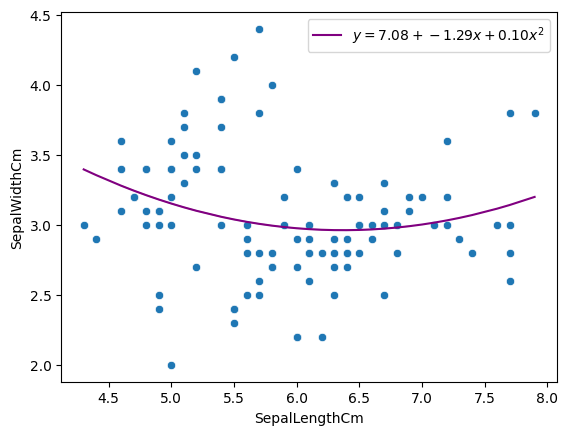

In [62]:
beta_quad_0, beta_quad_1, beta_quad_2 = fit_quadratic_regression(x, y)
sns.scatterplot(data=df, x='SepalLengthCm', y='SepalWidthCm')
x_sorted = np.sort(x)
y_quad_fit = beta_quad_0 + beta_quad_1 * x_sorted + beta_quad_2 * x_sorted**2
sns.lineplot(x=x_sorted, y=y_quad_fit, color='purple', label=rf'$y = {beta_quad_0:.2f} + {beta_quad_1:.2f} x + {beta_quad_2:.2f} x^2$')
plt.show()

Уравнение параболической регрессии здесь имеет малую кривизну, что говорит о слабой или почти отсутствующей выраженной квадратичной зависимости между признаками на данном интервале. Парабола лишь немного лучше улавливает разброс точек.

- Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы:
    - степенная функция: $ y = \beta_0x^{\beta_1} $;
    - показательная функция: $ y = \beta_0\exp(\beta_1x) $;
    - дробно-линейная функция: $ y = \cfrac1{\beta_0 + \beta_1x} $;
    - логарифмическая функция: $ y = \beta_0 + \beta_1\ln x $;
    - обратно пропорциональная функция: $ y = \beta_0 + \cfrac{\beta_1}x $;
    - дробно-рациональная функция: $ y = \cfrac x{\beta_0 + \beta_1x} $.

In [44]:
# Вариант 14 mod 6 = 2: показательная функция
def fit_exponential_regression(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    log_y = np.log(y)
    beta_0, beta_1 = fit_linear_regression(x, log_y)
    return np.exp(beta_0), beta_1

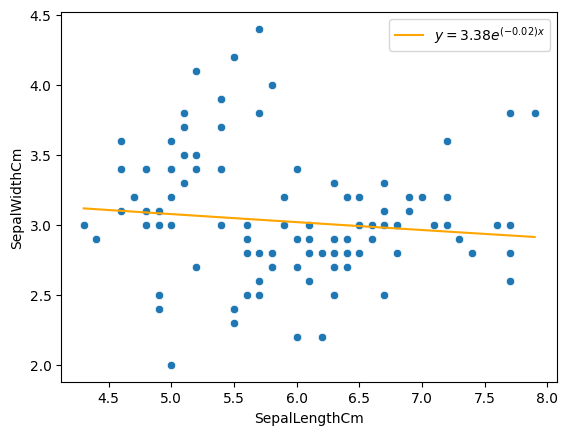

In [46]:
beta_exp_0, beta_exp_1 = fit_exponential_regression(x, y)
sns.scatterplot(data=df, x='SepalLengthCm', y='SepalWidthCm')
y_exp_fit = beta_exp_0 * np.exp(beta_exp_1 * x_sorted)
sns.lineplot(x=x_sorted, y=y_exp_fit, color='orange', label=rf'$y = {beta_exp_0:.2f} e^{{({beta_exp_1:.2f}) x}}$')
plt.show()

Экспоненциальная кривая визуально слабо отличается от прямой линии. Это связано с тем, что скорость изменения относительно мала, а показатели слабой линейной связи переносятся и на показатели экспоненты на данном участке.

- Вычислить следующие показатели качества регрессии для каждой кривой и сделать выводы:
    - теоретический коэффициент детерминации $ R^2 $;
    - средняя квадратическая ошибка $ S_{\varepsilon} $;
    - средняя ошибка аппроксимации (приближения) $ A $.

In [52]:
def determination_coefficient(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_residual / ss_total)

def mean_squared_error(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))

def mean_approximation_error(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs((y_true - y_pred) / y_true))) * 100

In [61]:
models = 'Линейная X на Y', 'Линейная Y на X', 'Квадратичная', 'Экспоненциальная'
y_trues = [y, x, y, y]
y_preds = [beta_xy_0 + beta_xy_1 * x,
           beta_yx_0 + beta_yx_1 * y,
           beta_quad_0 + beta_quad_1 * x + beta_quad_2 * x**2,
           beta_exp_0 * np.exp(beta_exp_1 * x)]

table_md = "| Модель | $R^2$ | $S_{\\varepsilon}$ | $\\bar{A}$ |\n|---|---|---|---|\n"
for model, y_true, y_pred in zip(models, y_trues, y_preds):
    r2 = determination_coefficient(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_approximation_error(y_true, y_pred)
    table_md += f"| **{model}** | {r2:.4f} | {mse:.4f} | {mae:.4f} |\n"

display_markdown(table_md, raw=True)

| Модель | $R^2$ | $S_{\varepsilon}$ | $\bar{A}$ |
|---|---|---|---|
| **Линейная X на Y** | 0.0153 | 0.1997 | 11.3967 |
| **Линейная Y на X** | 0.0153 | 0.7177 | 11.9162 |
| **Квадратичная** | 0.0497 | 0.1927 | 11.1200 |
| **Экспоненциальная** | 0.0103 | 0.2007 | 11.1964 |


Коэффициент детерминации $ R^2 $ для всех моделей очень низок, что свидетельствует о том, что рассматриваемые модели практически не объясняют дисперсию зависимой переменной. Ошибки для всех моделей примерно равны. Это подтверждает, что между длиной и шириной чашелистика очень слабая зависимость. По качеству аппроксимации квадратичная зависимость чуть лучше справляется за счет большего числа параметров параметров модели.

## Выводы
В ходе выполнения практической работы были вычислены параметры выборочных уравнений регрессии (линейной, квадратичной и экспоненциальной для заданного варианта), а также построены графики этих функций. Вычислены корреляционные отношения, с помощью которых проверено и экспериментально подтверждено неравенство $\eta \ge |r_{xy}|$. 
Сравнение различных моделей регрессии по показателям качества (коэффициенту детерминации, средней квадратической ошибке и средней ошибке аппроксимации) показало, что зависимость между рассматриваемыми признаками (длина и ширина чашелистика) крайне слаба, и ни одна из моделей не способна качественно объяснить эту вариативность на малом скоплении точек из выборки.